# Exploratory Neural-Behavior Analysis for the BCI2000 Joystick Task

This notebook combines the continuous neural signal with the behavioral/task states to look for channels whose activity is associated with specific parts of the experiment.

Main analyses:

- movement-related high-frequency broadband activity
- movement-related beta activity
- Automatic versus Controlled trials
- Ordered versus Pseudorandom blocks
- reaction-time correlation
- movement-time correlation
- joystick-path correlation
- target-direction tuning
- optional check for eye/gaze coordinate states

The analysis is exploratory. Significant associations do not prove that a signal causes behavior, and movement artifact, line noise, referencing, and electrode localization still need to be considered.


In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import welch
from scipy.stats import ttest_1samp, ttest_ind, spearmanr, f_oneway
from BCI2000Tools.FileReader import bcistream

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)


## 1. Select the BCI2000 recording


In [2]:
DAT_PATH = Path(
    r"C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat"
)

if not DAT_PATH.is_file():
    raise FileNotFoundError(
        f"File not found: {DAT_PATH}\n"
        "Edit DAT_PATH so it points to the BCI2000 .dat recording."
    )

print(f"Using: {DAT_PATH.resolve()}")


Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat


## 2. Open the file and decode the signal plus relevant states


In [3]:
stream = bcistream(str(DAT_PATH))

requested_states = [
    "CursorX",
    "CursorY",
    "TaskPhase",
    "TaskCondition",
    "TaskBlockType",
    "TargetAngle",
    "TargetX",
    "TargetY",
    "TaskBlock",
    "TaskTrial",
    "MovementStarted",
    "TargetHit",
    "Introduction",
    "PracticeTrial",
    "ReactionTimeMs",
    "MovementTimeMs",
    "TotalTimeMs",
    "JoystickXpos",
    "JoystickYpos",
    "JoystickButtons1",
    "Running",
    "Recording",
]

available_states = [
    name for name in requested_states
    if name in stream.statedefs
]

signal_raw, decoded_states = stream.decode(
    nsamp="all",
    states=available_states,
)

signal_raw = np.asarray(signal_raw)

n_channels = int(stream.nchan)
n_samples = int(stream.samples())
fs = float(stream.samplingfreq_hz)

if signal_raw.shape == (n_channels, n_samples):
    signal = signal_raw.T
elif signal_raw.shape == (n_samples, n_channels):
    signal = signal_raw
else:
    raise ValueError(f"Unexpected signal shape: {signal_raw.shape}")

states = {
    name: np.asarray(decoded_states[name]).ravel()
    for name in available_states
}

print(f"Signal shape: {signal.shape}  (samples x channels)")
print(f"Sampling rate: {fs:g} Hz")
print(f"Duration: {n_samples / fs / 60:.2f} minutes")
print(f"Decoded states: {len(states)}")


Signal shape: (1255100, 256)  (samples x channels)
Sampling rate: 2000 Hz
Duration: 10.46 minutes
Decoded states: 20


## 3. Identify intracranial contacts and attach the implant-target labels

The anatomical labels below come from the implantation sheet you provided. They describe the intended electrode target, not CT/MRI-confirmed localization of every individual contact.


In [4]:
channel_names = [
    str(name).strip()
    for name in stream.params["ChannelNames"]
]

implant_targets = {
    "AL": "L temporal pole",
    "BL": "L amygdala",
    "CL": "L hippocampal head",
    "DL": "L hippocampal tail",
    "EL": "L fusiform",
    "FL": "L orbitofrontal",
    "GL": "L opercular",
    "HL": "L anterior insula ventral",
    "IL": "L posterior insula",
    "AR": "R temporal pole",
    "BR": "R amygdala",
    "CR": "R hippocampal head",
    "DR": "R hippocampal tail",
    "ER": "R fusiform",
    "FR": "R orbitofrontal",
    "GR": "R opercular",
    "HR": "R anterior insula ventral",
    "IR": "R posterior insula",
}

rows = []

for zero_based_index, name in enumerate(channel_names):
    match = re.fullmatch(r"([A-Z]{2})(\d+)", name)

    if match and match.group(1) in implant_targets:
        prefix = match.group(1)

        rows.append({
            "signal_index": zero_based_index,
            "BCI2000_channel": zero_based_index + 1,
            "channel_name": name,
            "electrode": prefix,
            "contact": int(match.group(2)),
            "implant_target": implant_targets[prefix],
        })

intracranial_channels = pd.DataFrame(rows)

intracranial_indices = intracranial_channels["signal_index"].to_numpy()
intracranial_names = intracranial_channels["channel_name"].to_numpy()

print(f"Intracranial contacts retained: {len(intracranial_channels)}")
display(intracranial_channels.head(25))


Intracranial contacts retained: 202


,signal_index,BCI2000_channel,channel_name,electrode,contact,implant_target
0,0,1,AL1,AL,1,L temporal pole
1,1,2,AL2,AL,2,L temporal pole
2,2,3,AL3,AL,3,L temporal pole
3,3,4,AL4,AL,4,L temporal pole
4,6,7,AL5,AL,5,L temporal pole
5,7,8,AL6,AL,6,L temporal pole
6,8,9,AL7,AL,7,L temporal pole
7,9,10,AL8,AL,8,L temporal pole
8,10,11,AL9,AL,9,L temporal pole
9,11,12,AL10,AL,10,L temporal pole


## 4. Build one row per completed experimental trial

A completed trial is anchored on `TargetHit`. For each hit, the notebook finds the most recent `MovementStarted` onset with the same block and trial number.


In [5]:
def rising_edges(values):
    values = np.asarray(values)
    active = values > 0

    edges = np.flatnonzero(
        active[1:] & ~active[:-1]
    ) + 1

    if active.size and active[0]:
        edges = np.r_[0, edges]

    return edges.astype(int)


for needed in ["TaskBlock", "TaskTrial", "MovementStarted", "TargetHit"]:
    if needed not in states:
        raise KeyError(f"Required state missing: {needed}")

movement_onsets = rising_edges(states["MovementStarted"])
hit_samples = rising_edges(states["TargetHit"])

experimental_mask = np.ones(n_samples, dtype=bool)

if "Introduction" in states:
    experimental_mask &= states["Introduction"] == 0

experimental_mask &= states["TaskBlock"] > 0
experimental_mask &= states["TaskTrial"] > 0

if "PracticeTrial" in states:
    experimental_mask &= states["PracticeTrial"] == 0

movement_onsets = movement_onsets[experimental_mask[movement_onsets]]
hit_samples = hit_samples[experimental_mask[hit_samples]]

trial_rows = []

for hit in hit_samples:
    block = int(states["TaskBlock"][hit])
    trial = int(states["TaskTrial"][hit])

    candidates = movement_onsets[
        (movement_onsets <= hit)
        & (states["TaskBlock"][movement_onsets] == block)
        & (states["TaskTrial"][movement_onsets] == trial)
    ]

    if candidates.size == 0:
        continue

    onset = int(candidates[-1])

    row = {
        "block": block,
        "trial": trial,
        "movement_onset_sample": onset,
        "target_hit_sample": int(hit),
        "movement_onset_s": onset / fs,
        "target_hit_s": hit / fs,
    }

    for state_name in [
        "TaskCondition",
        "TaskBlockType",
        "TargetAngle",
        "ReactionTimeMs",
        "MovementTimeMs",
        "TotalTimeMs",
    ]:
        if state_name in states:
            row[state_name] = states[state_name][hit]

    if "JoystickXpos" in states and "JoystickYpos" in states:
        x = states["JoystickXpos"][onset:hit + 1].astype(float)
        y = states["JoystickYpos"][onset:hit + 1].astype(float)

        if len(x) >= 2:
            steps = np.hypot(np.diff(x), np.diff(y))
            row["joystick_path"] = np.nansum(steps)
            row["joystick_peak_step"] = np.nanmax(steps)
        else:
            row["joystick_path"] = np.nan
            row["joystick_peak_step"] = np.nan

    trial_rows.append(row)

trials = pd.DataFrame(trial_rows)

if trials.empty:
    raise RuntimeError(
        "No completed experimental trials could be matched to MovementStarted."
    )

if "TaskCondition" in trials:
    trials["condition"] = trials["TaskCondition"].map({
        0: "Automatic",
        1: "Controlled",
    })

if "TaskBlockType" in trials:
    trials["context"] = np.where(
        trials["TaskBlockType"] == 2,
        "Pseudorandom",
        "Ordered",
    )

if "TargetAngle" in trials:
    trials["target_angle_deg"] = trials["TargetAngle"] / 10.0

print(f"Matched completed trials: {len(trials)}")
display(trials.head(20))


Matched completed trials: 80


,block,trial,movement_onset_sample,target_hit_sample,movement_onset_s,target_hit_s,TaskCondition,TaskBlockType,TargetAngle,ReactionTimeMs,MovementTimeMs,TotalTimeMs,joystick_path,joystick_peak_step,condition,context,target_angle_deg
0,1,1,24600,28400,12.30,14.20,0,0,1276,949,1900,2849,37354.902718,674.569492,Automatic,Ordered,127.6
1,1,2,40300,42500,20.15,21.25,0,0,2256,751,1100,1851,14494.895456,232.963516,Automatic,Ordered,225.6
2,1,3,52900,53900,26.45,26.95,0,0,1509,450,500,950,9135.509951,316.077522,Automatic,Ordered,150.9
3,1,4,64100,65200,32.05,32.60,0,0,1253,500,550,1050,4909.604742,173.254149,Automatic,Ordered,125.3
4,1,5,74900,78600,37.45,39.30,0,0,2441,200,1850,2050,45117.367384,374.550397,Automatic,Ordered,244.1
5,1,6,96300,100300,48.15,50.15,0,0,210,700,2000,2700,23765.741839,274.696196,Automatic,Ordered,21.0
6,1,7,110600,111600,55.30,55.80,0,0,1274,549,501,1050,10129.161576,250.697028,Automatic,Ordered,127.4
7,1,8,121900,123300,60.95,61.65,0,0,2136,550,700,1251,8941.488188,186.590461,Automatic,Ordered,213.6
8,1,9,133700,133900,66.85,66.95,0,0,3353,499,100,598,2010.027207,181.727818,Automatic,Ordered,335.3
9,1,10,144100,145300,72.05,72.65,0,0,3008,500,599,1099,10623.547812,192.000000,Automatic,Ordered,300.8


## 5. Behavioral summary


In [6]:
summary = {
    "completed_trials": len(trials),
}

if "condition" in trials:
    summary["automatic_trials"] = int((trials["condition"] == "Automatic").sum())
    summary["controlled_trials"] = int((trials["condition"] == "Controlled").sum())

if "context" in trials:
    summary["ordered_trials"] = int((trials["context"] == "Ordered").sum())
    summary["pseudorandom_trials"] = int((trials["context"] == "Pseudorandom").sum())

if "target_angle_deg" in trials:
    summary["target_directions"] = int(trials["target_angle_deg"].nunique())

display(pd.Series(summary, name="count").to_frame())


,count
completed_trials,80
automatic_trials,40
controlled_trials,40
ordered_trials,20
pseudorandom_trials,60
target_directions,77


## 6. Calculate movement-related neural power

For each trial and each intracranial contact, compare:

- pre-movement: -0.75 to -0.25 s relative to `MovementStarted`
- movement: 0.00 to +0.50 s relative to `MovementStarted`

Frequency bands:

- beta: 13 to 30 Hz
- HFB: 70 to 150 Hz

The HFB calculation excludes frequencies within 2 Hz of 120 Hz to reduce contamination from the 60 Hz harmonic.

The output is:

`10 * log10(movement power / pre-movement power)`

Positive values mean power increased during movement. Negative values mean power decreased.


In [7]:
BASELINE_WINDOW_S = (-0.75, -0.25)
MOVEMENT_WINDOW_S = (0.00, 0.50)

BANDS = {
    "beta": (13.0, 30.0),
    "hfb": (70.0, 150.0),
}

LINE_NOISE_FREQS = (60.0, 120.0, 180.0)
LINE_NOISE_HALF_WIDTH_HZ = 2.0


def spectral_density(segment, fs):
    nperseg = min(
        segment.shape[0],
        max(64, int(round(fs * 0.25))),
    )

    f, pxx = welch(
        segment,
        fs=fs,
        axis=0,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
    )

    return f, pxx


def integrate_band(f, pxx, low, high):
    mask = (f >= low) & (f <= high)

    for line_freq in LINE_NOISE_FREQS:
        mask &= (
            np.abs(f - line_freq)
            > LINE_NOISE_HALF_WIDTH_HZ
        )

    if mask.sum() < 2:
        raise ValueError(
            f"Not enough frequency bins for {low}-{high} Hz."
        )

    return np.trapezoid(
        pxx[mask],
        f[mask],
        axis=0,
    )


band_responses = {
    band_name: []
    for band_name in BANDS
}

kept_trial_rows = []

for trial_index, row in trials.iterrows():
    onset = int(row["movement_onset_sample"])

    b0 = onset + int(round(BASELINE_WINDOW_S[0] * fs))
    b1 = onset + int(round(BASELINE_WINDOW_S[1] * fs))

    m0 = onset + int(round(MOVEMENT_WINDOW_S[0] * fs))
    m1 = onset + int(round(MOVEMENT_WINDOW_S[1] * fs))

    if b0 < 0 or b1 > n_samples or m0 < 0 or m1 > n_samples:
        continue

    baseline_segment = signal[
        b0:b1,
        intracranial_indices,
    ].astype(np.float64)

    movement_segment = signal[
        m0:m1,
        intracranial_indices,
    ].astype(np.float64)

    f_base, psd_base = spectral_density(baseline_segment, fs)
    f_move, psd_move = spectral_density(movement_segment, fs)

    if not np.allclose(f_base, f_move):
        raise RuntimeError("Baseline and movement PSD frequencies differ.")

    for band_name, (low, high) in BANDS.items():
        base_power = integrate_band(
            f_base,
            psd_base,
            low,
            high,
        )

        move_power = integrate_band(
            f_move,
            psd_move,
            low,
            high,
        )

        eps = np.finfo(float).tiny

        response_db = 10 * np.log10(
            (move_power + eps)
            / (base_power + eps)
        )

        band_responses[band_name].append(response_db)

    kept_trial_rows.append(trial_index)

for band_name in band_responses:
    band_responses[band_name] = np.vstack(
        band_responses[band_name]
    )

neural_trials = trials.loc[
    kept_trial_rows
].reset_index(drop=True)

print(f"Trials retained: {len(neural_trials)}")
print(f"Channels analyzed: {len(intracranial_channels)}")
print(f"HFB matrix: {band_responses['hfb'].shape}")
print(f"Beta matrix: {band_responses['beta'].shape}")


Trials retained: 80
Channels analyzed: 202
HFB matrix: (80, 202)
Beta matrix: (80, 202)


## 7. Multiple-comparison correction


In [8]:
def fdr_bh(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(p_values.shape, np.nan)

    valid = np.isfinite(p_values)

    if not valid.any():
        return q_values

    p = p_values[valid]
    order = np.argsort(p)
    ranked = p[order]

    m = len(ranked)

    adjusted = (
        ranked
        * m
        / np.arange(1, m + 1)
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(adjusted, 0, 1)

    unsorted = np.empty_like(adjusted)
    unsorted[order] = adjusted

    q_values[valid] = unsorted

    return q_values


## 8. Find channels whose activity changes around movement onset

For every intracranial channel, test whether the mean movement-related power change differs from 0 dB.


In [9]:
results = intracranial_channels[
    [
        "BCI2000_channel",
        "channel_name",
        "electrode",
        "contact",
        "implant_target",
    ]
].copy()

for band_name, response in band_responses.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        test = ttest_1samp(
            response,
            popmean=0,
            axis=0,
            nan_policy="omit",
        )

    results[f"{band_name}_mean_change_db"] = np.nanmean(
        response,
        axis=0,
    )

    results[f"{band_name}_movement_p"] = test.pvalue
    results[f"{band_name}_movement_q"] = fdr_bh(
        test.pvalue
    )

display(
    results.sort_values(
        ["hfb_movement_q", "hfb_mean_change_db"],
        ascending=[True, False],
    )[
        [
            "channel_name",
            "implant_target",
            "hfb_mean_change_db",
            "hfb_movement_p",
            "hfb_movement_q",
            "beta_mean_change_db",
            "beta_movement_q",
        ]
    ].head(30)
)


,channel_name,implant_target,hfb_mean_change_db,hfb_movement_p,hfb_movement_q,beta_mean_change_db,beta_movement_q
0,AL1,L temporal pole,-2.094022,6.277618e-16,1.268079e-13,-0.764049,0.397557
11,BL2,L amygdala,-1.892508,1.550202e-14,1.565704e-12,-0.411894,0.804736
12,BL3,L amygdala,-1.975453,2.808266e-14,1.890899e-12,-0.287771,0.835846
14,BL5,L amygdala,-1.854363,1.033543e-13,4.175515e-12,-0.534295,0.590457
13,BL4,L amygdala,-1.871987,9.200859e-14,4.175515e-12,-0.328296,0.804736
123,CR1,R hippocampal head,-1.811318,1.733091e-13,5.834738e-12,-0.561985,0.558865
1,AL2,L temporal pole,-1.847840,2.429404e-13,7.010566e-12,-1.142595,0.201853
124,CR2,R hippocampal head,-1.721811,3.915212e-13,9.885909e-12,-0.713329,0.357230
70,HL1,L anterior insula ventral,-1.642421,5.738800e-13,1.159238e-11,-0.249274,0.828209
15,BL6,L amygdala,-1.769569,5.533749e-13,1.159238e-11,-0.524366,0.558865


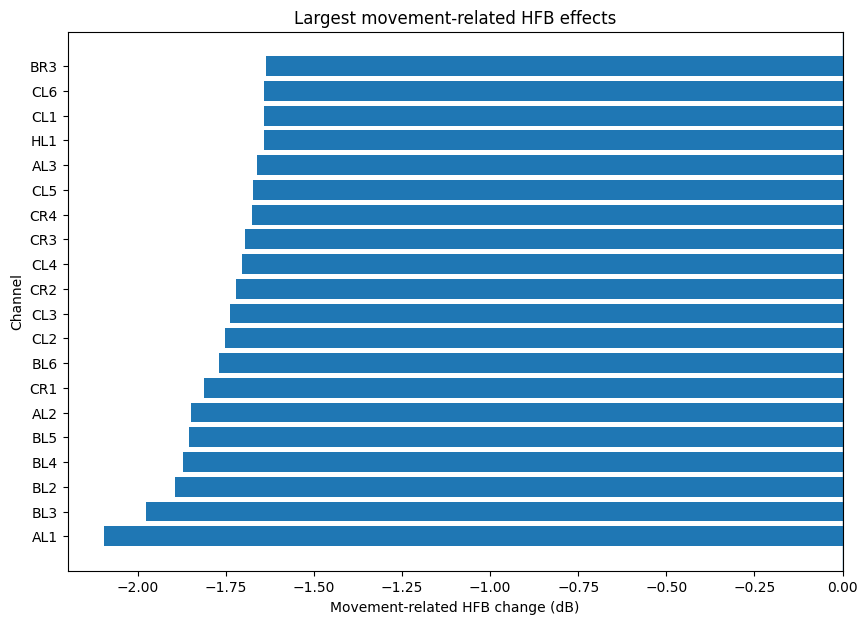

In [10]:
N_TO_PLOT = 20

plot_table = (
    results
    .assign(
        absolute_hfb_change=
        results["hfb_mean_change_db"].abs()
    )
    .sort_values(
        "absolute_hfb_change",
        ascending=False,
    )
    .head(N_TO_PLOT)
    .sort_values("hfb_mean_change_db")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_table["channel_name"],
    plot_table["hfb_mean_change_db"],
)

ax.axvline(0, linewidth=1)
ax.set_xlabel("Movement-related HFB change (dB)")
ax.set_ylabel("Channel")
ax.set_title("Largest movement-related HFB effects")

plt.show()


## 9. Automatic versus Controlled

`TaskCondition` is treated as:

- 0 = Automatic
- 1 = Controlled

Positive difference means the HFB movement response was larger during Controlled trials.


In [11]:
if "condition" in neural_trials.columns:
    auto_mask = (
        neural_trials["condition"] == "Automatic"
    ).to_numpy()

    controlled_mask = (
        neural_trials["condition"] == "Controlled"
    ).to_numpy()

    if auto_mask.sum() >= 2 and controlled_mask.sum() >= 2:
        hfb = band_responses["hfb"]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            test = ttest_ind(
                hfb[controlled_mask],
                hfb[auto_mask],
                axis=0,
                equal_var=False,
                nan_policy="omit",
            )

        difference = (
            np.nanmean(hfb[controlled_mask], axis=0)
            - np.nanmean(hfb[auto_mask], axis=0)
        )

        results["controlled_minus_automatic_hfb_db"] = difference
        results["condition_p"] = test.pvalue
        results["condition_q"] = fdr_bh(test.pvalue)

        display(
            results.sort_values("condition_q")[
                [
                    "channel_name",
                    "implant_target",
                    "controlled_minus_automatic_hfb_db",
                    "condition_p",
                    "condition_q",
                ]
            ].head(30)
        )
    else:
        print("Not enough Automatic and Controlled trials.")
else:
    print("TaskCondition was unavailable.")


,channel_name,implant_target,controlled_minus_automatic_hfb_db,condition_p,condition_q
0,AL1,L temporal pole,-0.448391,0.281256,0.962071
1,AL2,L temporal pole,-0.211381,0.618022,0.962071
2,AL3,L temporal pole,-0.456756,0.280398,0.962071
3,AL4,L temporal pole,-0.334061,0.418552,0.962071
4,AL5,L temporal pole,-0.531509,0.195889,0.962071
5,AL6,L temporal pole,-0.314119,0.432628,0.962071
6,AL7,L temporal pole,-0.238393,0.566651,0.962071
7,AL8,L temporal pole,-0.348765,0.416347,0.962071
8,AL9,L temporal pole,-0.604090,0.183811,0.962071
9,AL10,L temporal pole,-0.775741,0.101187,0.962071


## 10. Ordered versus Pseudorandom

`TaskBlockType == 2` is treated as Pseudorandom. Other experimental block types are grouped as Ordered.


In [12]:
if "context" in neural_trials.columns:
    ordered_mask = (
        neural_trials["context"] == "Ordered"
    ).to_numpy()

    random_mask = (
        neural_trials["context"] == "Pseudorandom"
    ).to_numpy()

    if ordered_mask.sum() >= 2 and random_mask.sum() >= 2:
        hfb = band_responses["hfb"]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            test = ttest_ind(
                hfb[random_mask],
                hfb[ordered_mask],
                axis=0,
                equal_var=False,
                nan_policy="omit",
            )

        difference = (
            np.nanmean(hfb[random_mask], axis=0)
            - np.nanmean(hfb[ordered_mask], axis=0)
        )

        results["pseudorandom_minus_ordered_hfb_db"] = difference
        results["context_p"] = test.pvalue
        results["context_q"] = fdr_bh(test.pvalue)

        display(
            results.sort_values("context_q")[
                [
                    "channel_name",
                    "implant_target",
                    "pseudorandom_minus_ordered_hfb_db",
                    "context_p",
                    "context_q",
                ]
            ].head(30)
        )
    else:
        print("Not enough Ordered and Pseudorandom trials.")
else:
    print("TaskBlockType was unavailable.")


,channel_name,implant_target,pseudorandom_minus_ordered_hfb_db,context_p,context_q
86,HL17,L anterior insula ventral,2.065318,0.000109,0.02199
0,AL1,L temporal pole,-0.148344,0.740657,0.99703
2,AL3,L temporal pole,0.074964,0.863857,0.99703
1,AL2,L temporal pole,0.029458,0.948926,0.99703
4,AL5,L temporal pole,0.017144,0.970465,0.99703
5,AL6,L temporal pole,-0.144449,0.734642,0.99703
6,AL7,L temporal pole,-0.021279,0.961224,0.99703
3,AL4,L temporal pole,0.082309,0.847936,0.99703
8,AL9,L temporal pole,-0.217020,0.651616,0.99703
9,AL10,L temporal pole,-0.298840,0.534453,0.99703


## 11. Correlate HFB with reaction time, movement time, and joystick movement

Spearman correlation is used for trial-by-trial associations.

This is useful for finding channels where the neural response tracks how quickly or strongly the participant behaved.


In [13]:
def channelwise_spearman(response_matrix, behavior):
    behavior = np.asarray(behavior, dtype=float)

    rho = np.full(response_matrix.shape[1], np.nan)
    p = np.full(response_matrix.shape[1], np.nan)

    for ch in range(response_matrix.shape[1]):
        neural = response_matrix[:, ch]

        valid = (
            np.isfinite(neural)
            & np.isfinite(behavior)
        )

        if valid.sum() < 5:
            continue

        if (
            np.unique(neural[valid]).size < 2
            or np.unique(behavior[valid]).size < 2
        ):
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            stat = spearmanr(
                neural[valid],
                behavior[valid],
            )

        rho[ch] = stat.statistic
        p[ch] = stat.pvalue

    return rho, p, fdr_bh(p)


hfb = band_responses["hfb"]

behavior_columns = {
    "reaction_time": "ReactionTimeMs",
    "movement_time": "MovementTimeMs",
    "joystick_path": "joystick_path",
}

for short_name, column in behavior_columns.items():
    if column not in neural_trials.columns:
        continue

    behavior = neural_trials[column].astype(float).to_numpy()

    if column in {"ReactionTimeMs", "MovementTimeMs"}:
        behavior = behavior.copy()
        behavior[behavior <= 0] = np.nan

    rho, p, q = channelwise_spearman(
        hfb,
        behavior,
    )

    results[f"{short_name}_rho"] = rho
    results[f"{short_name}_p"] = p
    results[f"{short_name}_q"] = q

show_columns = [
    "channel_name",
    "implant_target",
]

for short_name in behavior_columns:
    if f"{short_name}_rho" in results.columns:
        show_columns.extend([
            f"{short_name}_rho",
            f"{short_name}_q",
        ])

if "reaction_time_q" in results.columns:
    ranked_behavior = results.sort_values(
        "reaction_time_q"
    )
else:
    ranked_behavior = results.copy()

display(
    ranked_behavior[show_columns].head(30)
)


,channel_name,implant_target,reaction_time_rho,reaction_time_q,movement_time_rho,movement_time_q,joystick_path_rho,joystick_path_q
0,AL1,L temporal pole,-0.274738,0.225705,0.096174,0.985831,0.082513,0.977703
1,AL2,L temporal pole,-0.253239,0.225705,0.132521,0.985831,0.108439,0.977703
2,AL3,L temporal pole,-0.230203,0.225705,0.069707,0.985831,0.027872,0.977703
3,AL4,L temporal pole,-0.240853,0.225705,0.044858,0.985831,0.034412,0.977703
4,AL5,L temporal pole,-0.260956,0.225705,0.028776,0.985831,0.008603,0.977703
5,AL6,L temporal pole,-0.307696,0.225705,0.043685,0.985831,0.052555,0.977703
6,AL7,L temporal pole,-0.228749,0.225705,0.071735,0.985831,0.069902,0.977703
7,AL8,L temporal pole,-0.231869,0.225705,0.116580,0.985831,0.124613,0.977703
11,BL2,L amygdala,-0.259995,0.225705,0.012659,0.985831,0.014416,0.977703
10,BL1,L amygdala,-0.232971,0.225705,0.012096,0.985831,0.011932,0.977703


## 12. Target-direction tuning

This asks whether movement-related HFB differs across `TargetAngle`.

Only target directions with at least 3 analyzed trials are included.


In [14]:
if "target_angle_deg" in neural_trials.columns:
    angles = neural_trials["target_angle_deg"].to_numpy()

    angle_counts = pd.Series(angles).value_counts()
    usable_angles = angle_counts[
        angle_counts >= 3
    ].index.to_numpy()

    print("Usable target directions:")
    display(
        angle_counts.loc[usable_angles]
        .sort_index()
        .rename("n_trials")
        .to_frame()
    )

    if len(usable_angles) >= 2:
        direction_p = np.full(
            hfb.shape[1],
            np.nan,
        )

        direction_f = np.full(
            hfb.shape[1],
            np.nan,
        )

        for ch in range(hfb.shape[1]):
            groups = [
                hfb[angles == angle, ch]
                for angle in usable_angles
            ]

            groups = [
                group[np.isfinite(group)]
                for group in groups
            ]

            if any(len(group) < 3 for group in groups):
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                test = f_oneway(*groups)

            direction_f[ch] = test.statistic
            direction_p[ch] = test.pvalue

        results["target_direction_F"] = direction_f
        results["target_direction_p"] = direction_p
        results["target_direction_q"] = fdr_bh(
            direction_p
        )

        display(
            results.sort_values("target_direction_q")[
                [
                    "channel_name",
                    "implant_target",
                    "target_direction_F",
                    "target_direction_p",
                    "target_direction_q",
                ]
            ].head(30)
        )
    else:
        print("Not enough repeated target directions.")
else:
    print("TargetAngle was unavailable.")


Usable target directions:


,n_trials


Not enough repeated target directions.


## 13. Candidate task-related channels

A channel is flagged when one of the available tests survives FDR correction at `q < 0.05`.

This is a screening list, not a final physiological conclusion.


In [15]:
Q_THRESHOLD = 0.05

def association_flags(row):
    flags = []

    if (
        pd.notna(row.get("hfb_movement_q", np.nan))
        and row["hfb_movement_q"] < Q_THRESHOLD
    ):
        direction = (
            "increase"
            if row["hfb_mean_change_db"] > 0
            else "decrease"
        )
        flags.append(f"movement HFB {direction}")

    if (
        pd.notna(row.get("beta_movement_q", np.nan))
        and row["beta_movement_q"] < Q_THRESHOLD
    ):
        direction = (
            "increase"
            if row["beta_mean_change_db"] > 0
            else "decrease"
        )
        flags.append(f"movement beta {direction}")

    optional_tests = {
        "condition_q": "Automatic/Controlled",
        "context_q": "Ordered/Pseudorandom",
        "reaction_time_q": "reaction time",
        "movement_time_q": "movement time",
        "joystick_path_q": "joystick path",
        "target_direction_q": "target direction",
    }

    for q_column, label in optional_tests.items():
        if (
            pd.notna(row.get(q_column, np.nan))
            and row[q_column] < Q_THRESHOLD
        ):
            flags.append(label)

    return "; ".join(flags)


results["associations"] = results.apply(
    association_flags,
    axis=1,
)

results["n_significant_associations"] = (
    results["associations"].apply(
        lambda text:
        0 if text == "" else len(text.split("; "))
    )
)

candidate_channels = (
    results[
        results["n_significant_associations"] > 0
    ]
    .sort_values(
        [
            "n_significant_associations",
            "hfb_movement_q",
        ],
        ascending=[False, True],
    )
)

if candidate_channels.empty:
    print(
        "No channels survived q < 0.05 in the analyses run so far."
    )

    display(
        results.sort_values("hfb_movement_q")[
            [
                "channel_name",
                "implant_target",
                "hfb_mean_change_db",
                "hfb_movement_p",
                "hfb_movement_q",
            ]
        ].head(20)
    )
else:
    display(
        candidate_channels[
            [
                "channel_name",
                "implant_target",
                "n_significant_associations",
                "associations",
                "hfb_mean_change_db",
                "hfb_movement_q",
            ]
        ].head(50)
    )


,channel_name,implant_target,n_significant_associations,associations,hfb_mean_change_db,hfb_movement_q
101,IL14,L posterior insula,2,movement HFB decrease; movement beta decrease,-1.318508,1.806388e-09
193,IR7,R posterior insula,2,movement HFB decrease; movement beta decrease,-1.094089,1.924181e-09
102,IL15,L posterior insula,2,movement HFB decrease; movement beta decrease,-1.250427,1.651309e-08
100,IL13,L posterior insula,2,movement HFB decrease; movement beta decrease,-1.247763,1.774893e-08
87,HL18,L anterior insula ventral,2,movement HFB decrease; movement beta decrease,-1.256468,2.294167e-08
17,BL8,L amygdala,2,movement HFB decrease; movement beta decrease,-1.138456,1.348579e-06
9,AL10,L temporal pole,2,movement HFB decrease; movement beta decrease,-1.246263,1.406837e-06
21,BL12,L amygdala,2,movement HFB decrease; movement beta decrease,-1.135544,1.521392e-06
0,AL1,L temporal pole,1,movement HFB decrease,-2.094022,1.268079e-13
11,BL2,L amygdala,1,movement HFB decrease,-1.892508,1.565704e-12


## 14. Region-level descriptive summary

This groups contacts by the intended implantation target.

The contacts are not independent observations, so this is descriptive rather than a formal region-level statistical test.


In [16]:
region_summary = (
    results
    .groupby("implant_target", observed=True)
    .agg(
        n_contacts=("channel_name", "size"),
        mean_hfb_change_db=(
            "hfb_mean_change_db",
            "mean",
        ),
        median_hfb_change_db=(
            "hfb_mean_change_db",
            "median",
        ),
    )
    .sort_values(
        "mean_hfb_change_db",
        ascending=False,
    )
)

display(region_summary)


,n_contacts,mean_hfb_change_db,median_hfb_change_db
implant_target,,,
R posterior insula,15,-0.956075,-1.297035
R opercular,5,-0.987529,-0.988180
R anterior insula ventral,15,-1.026618,-1.150412
R orbitofrontal,10,-1.057705,-1.157992
L posterior insula,15,-1.126412,-1.250427
R hippocampal tail,12,-1.189434,-1.238553
L anterior insula ventral,18,-1.230867,-1.292603
L orbitofrontal,8,-1.240882,-1.189069
R fusiform,10,-1.266327,-1.269392


## 15. Check for eye/gaze states

The populated-state list you supplied did not contain explicit gaze-position coordinates.

This cell checks the actual file for any state containing `eye` or `gaze`. If no coordinate states are present, a true gaze-position correlation cannot be performed from this recording.


In [17]:
eye_or_gaze_states = [
    name
    for name in stream.statedefs.keys()
    if (
        "eye" in name.lower()
        or "gaze" in name.lower()
    )
]

if eye_or_gaze_states:
    print("Eye/gaze-related states found:")
    for name in eye_or_gaze_states:
        print(" ", name)
else:
    print(
        "No eye/gaze-related BCI2000 states were found."
    )

coordinate_like = [
    name for name in eye_or_gaze_states
    if (
        "gazex" in name.lower()
        or "gazey" in name.lower()
        or "positionx" in name.lower()
        or "positiony" in name.lower()
    )
]

if not coordinate_like:
    print(
        "\nNo obvious gaze-coordinate states were found, "
        "so gaze-position correlation is skipped."
    )


Eye/gaze-related states found:
  EyetrackerTime
  EyetrackerLeftEyeValidity
  EyetrackerLeftEyeOpennessValidity
  EyetrackerLeftPupilSize
  EyetrackerLeftEyeOpenness
  EyetrackerLeftEyeGazeX
  EyetrackerLeftEyeGazeY
  EyetrackerLeftEyePosX
  EyetrackerLeftEyePosY
  EyetrackerLeftEyeDist
  EyetrackerRightEyeValidity
  EyetrackerRightEyeOpennessValidity
  EyetrackerRightPupilSize
  EyetrackerRightEyeOpenness
  EyetrackerRightEyeGazeX
  EyetrackerRightEyeGazeY
  EyetrackerRightEyePosX
  EyetrackerRightEyePosY
  EyetrackerRightEyeDist
  GazeCorrectionMode


## 16. Inspect the strongest movement-HFB candidate


Channel:        AL1
Implant target: L temporal pole
Mean HFB change: -2.094 dB
Movement q:     1.268e-13


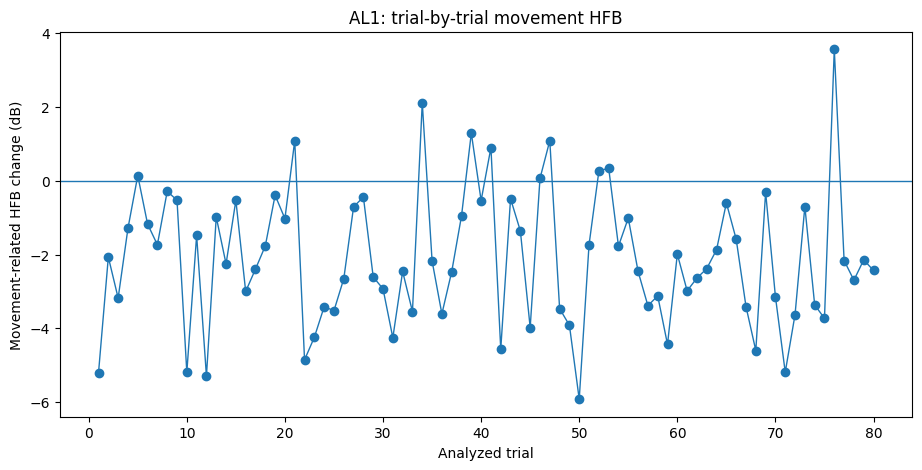

In [18]:
CHANNEL_TO_VIEW = (
    results
    .sort_values("hfb_movement_q")
    .iloc[0]["channel_name"]
)

channel_position = np.flatnonzero(
    intracranial_names == CHANNEL_TO_VIEW
)

if channel_position.size != 1:
    raise ValueError(
        f"Could not uniquely identify {CHANNEL_TO_VIEW}"
    )

channel_position = int(channel_position[0])

channel_info = results.loc[
    results["channel_name"] == CHANNEL_TO_VIEW
].iloc[0]

trial_hfb = hfb[:, channel_position]

print(f"Channel:        {CHANNEL_TO_VIEW}")
print(f"Implant target: {channel_info['implant_target']}")
print(
    f"Mean HFB change: "
    f"{channel_info['hfb_mean_change_db']:.3f} dB"
)
print(
    f"Movement q:     "
    f"{channel_info['hfb_movement_q']:.4g}"
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    np.arange(1, len(trial_hfb) + 1),
    trial_hfb,
    marker="o",
    linewidth=1,
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Analyzed trial")
ax.set_ylabel("Movement-related HFB change (dB)")
ax.set_title(
    f"{CHANNEL_TO_VIEW}: trial-by-trial movement HFB"
)

plt.show()


## 17. Reaction-time scatter plot for the selected channel


Spearman rho = -0.275, p = 0.01365


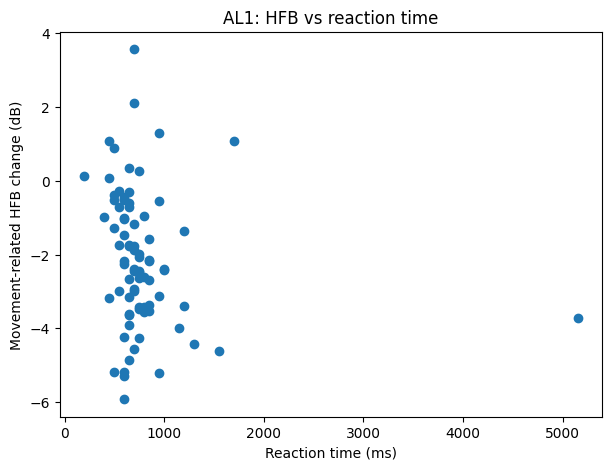

In [19]:
if "ReactionTimeMs" in neural_trials.columns:
    reaction_time = (
        neural_trials["ReactionTimeMs"]
        .astype(float)
        .to_numpy()
    )

    reaction_time[
        reaction_time <= 0
    ] = np.nan

    valid = (
        np.isfinite(reaction_time)
        & np.isfinite(trial_hfb)
    )

    if valid.sum() >= 5:
        stat = spearmanr(
            reaction_time[valid],
            trial_hfb[valid],
        )

        print(
            f"Spearman rho = {stat.statistic:.3f}, "
            f"p = {stat.pvalue:.4g}"
        )

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.scatter(
            reaction_time[valid],
            trial_hfb[valid],
        )

        ax.set_xlabel("Reaction time (ms)")
        ax.set_ylabel("Movement-related HFB change (dB)")
        ax.set_title(
            f"{CHANNEL_TO_VIEW}: HFB vs reaction time"
        )

        plt.show()
    else:
        print("Not enough valid reaction-time trials.")
else:
    print("ReactionTimeMs was unavailable.")


## Interpretation

The strongest evidence for a task-related channel would be a reproducible pattern such as:

- HFB consistently increasing after `MovementStarted`
- beta consistently decreasing around movement
- different HFB responses in Automatic versus Controlled trials
- different responses in Ordered versus Pseudorandom blocks
- trial-by-trial correlation with reaction time, movement time, or joystick movement
- different HFB responses for different target directions

Any candidate should still be checked for line noise, movement artifact, bad contacts, referencing effects, consistency across trials, and precise contact localization on post-implant imaging.
